# 06 — Modelos

**Inputs:** `aves_train.parquet`, `aves_predict.parquet`, `mamiferos_train.parquet`, `mamiferos_predict.parquet`  
**Output:** `data/processed/predicciones.parquet`

**Modelos:** Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN  
**Estrategia imbalance:** `class_weight='balanced'` + métricas ROC-AUC / PR-AUC / F1  
**Validación:** Stratified K-Fold (k=5)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mlflow
import mlflow.sklearn
import dagshub

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

sns.set_theme(style='whitegrid')
DATA = Path('../data/processed')
SEED = 42

aves_tr = pd.read_parquet(DATA / 'aves_train.parquet',        engine='fastparquet')
aves_pr = pd.read_parquet(DATA / 'aves_predict.parquet',      engine='fastparquet')
mam_tr  = pd.read_parquet(DATA / 'mamiferos_train.parquet',   engine='fastparquet')
mam_pr  = pd.read_parquet(DATA / 'mamiferos_predict.parquet', engine='fastparquet')

META = ['species', 'iucn_categoria', 'threatened']

def split_xy(df):
    feat_cols = [c for c in df.columns if c not in META]
    return df[feat_cols], df['threatened'].astype(int)

X_aves, y_aves = split_xy(aves_tr)
X_mam,  y_mam  = split_xy(mam_tr)
X_aves_pred = aves_pr[[c for c in aves_pr.columns if c not in META]]
X_mam_pred  = mam_pr[[c  for c in mam_pr.columns  if c not in META]]

print(f'Aves  train:   {X_aves.shape}  | threatened: {y_aves.sum()} / {len(y_aves)}')
print(f'Mamif train:   {X_mam.shape}   | threatened: {y_mam.sum()} / {len(y_mam)}')
print(f'Aves  predict: {X_aves_pred.shape}')
print(f'Mamif predict: {X_mam_pred.shape}')

Aves  train:   (1313, 64)  | threatened: 36 / 1313
Mamif train:   (189, 29)   | threatened: 13 / 189
Aves  predict: (165, 64)
Mamif predict: (37, 29)


In [13]:
# MLflow tracking via DagsHub
dagshub.init(repo_owner='krilinxito', repo_name='bioAlerta', mlflow=True)
mlflow.set_experiment('bioalerta-modelos')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=5c73e314-b5e2-49be-80e7-4a4f428df830&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=22b73c7b8c12054e50e1bc8beae0d025882902ed6d3434944b3812805ba7444e




Accessing as krilinxito

Initialized MLflow to track repo "krilinxito/bioAlerta"

Repository krilinxito/bioAlerta initialized!

2026/04/01 23:17:15 INFO mlflow.tracking.fluent: Experiment with name 'bioalerta-modelos' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/720370e2e13c446da93ea18d8bfb8ca3', creation_time=1775099835173, experiment_id='0', last_update_time=1775099835173, lifecycle_stage='active', name='bioalerta-modelos', tags={}, workspace='default'>

## 1. Definición de modelos

In [14]:
def get_models(seed=SEED):
    """Siempre devuelve instancias nuevas e independientes."""
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=2000,
                                       solver='lbfgs', random_state=seed))
        ]),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            max_features='sqrt', random_state=seed, n_jobs=-1
        ),
        'Gradient Boosting': HistGradientBoostingClassifier(
            class_weight='balanced', max_iter=300,
            learning_rate=0.05, random_state=seed
        ),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(class_weight='balanced', probability=True,
                        kernel='rbf', random_state=seed))
        ]),
        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1))
        ]),
    }

SCORING = ['roc_auc', 'average_precision', 'f1']
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Modelos:', list(get_models().keys()))

Modelos: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN']


## 2. Cross-validation — Aves

In [15]:
def evaluar_modelos(X, y, clase):
    resultados = []
    for nombre, modelo in get_models().items():
        print(f'  {nombre}...', end=' ', flush=True)
        cv = cross_validate(modelo, X, y, cv=CV, scoring=SCORING, n_jobs=-1)

        roc_auc     = cv['test_roc_auc'].mean()
        roc_auc_std = cv['test_roc_auc'].std()
        pr_auc      = cv['test_average_precision'].mean()
        pr_auc_std  = cv['test_average_precision'].std()
        f1          = cv['test_f1'].mean()
        f1_std      = cv['test_f1'].std()

        with mlflow.start_run(run_name=f"{clase}_{nombre}"):
            mlflow.log_param("clase",     clase)
            mlflow.log_param("modelo",    nombre)
            mlflow.log_param("cv_folds",  5)
            mlflow.log_param("seed",      SEED)
            mlflow.log_metric("roc_auc",     roc_auc)
            mlflow.log_metric("roc_auc_std", roc_auc_std)
            mlflow.log_metric("pr_auc",      pr_auc)
            mlflow.log_metric("pr_auc_std",  pr_auc_std)
            mlflow.log_metric("f1",          f1)
            mlflow.log_metric("f1_std",      f1_std)

        resultados.append({
            'modelo':   nombre,
            'ROC-AUC':  roc_auc,
            'ROC-AUC±': roc_auc_std,
            'PR-AUC':   pr_auc,
            'PR-AUC±':  pr_auc_std,
            'F1':       f1,
            'F1±':      f1_std,
        })
        print(f'ROC-AUC={roc_auc:.3f}')
    return pd.DataFrame(resultados).set_index('modelo')

print('=== AVES ===')
res_aves = evaluar_modelos(X_aves, y_aves, clase='Aves')
print()
print(res_aves.round(3).to_string())

=== AVES ===
  Logistic Regression... 🏃 View run Aves_Logistic Regression at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/2d54972f43e542bdbbb0e9dafb367f6b
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0
ROC-AUC=0.797
  Random Forest... 🏃 View run Aves_Random Forest at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/2bccd70217e44113acfc20bd06f8650c
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0
ROC-AUC=0.848
  Gradient Boosting... 🏃 View run Aves_Gradient Boosting at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/519ef3ef2856420ab790e043a851e8d1
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0
ROC-AUC=0.786
  SVM... 🏃 View run Aves_SVM at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/c383f5771f834422af00ee45020f2594
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlfl

## 3. Cross-validation — Mamíferos

In [16]:
print('=== MAMÍFEROS ===')
res_mam = evaluar_modelos(X_mam, y_mam, clase='Mamiferos')
print()
print(res_mam.round(3).to_string())

=== MAMÍFEROS ===
  Logistic Regression... 🏃 View run Mamiferos_Logistic Regression at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/323a922542c448aaac95f66d02a322d2
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0
ROC-AUC=0.707
  Random Forest... 🏃 View run Mamiferos_Random Forest at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/949ba8621ecc41b4bbf65990128674a1
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0
ROC-AUC=0.792
  Gradient Boosting... 🏃 View run Mamiferos_Gradient Boosting at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/ffe77a03e6944584b4fcf77e7d90b55f
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0
ROC-AUC=0.728
  SVM... 🏃 View run Mamiferos_SVM at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/33b755c0b0a545259c9e4ee687006a33
🧪 View experiment at: https://dagshub.com/

## 4. Comparación visual

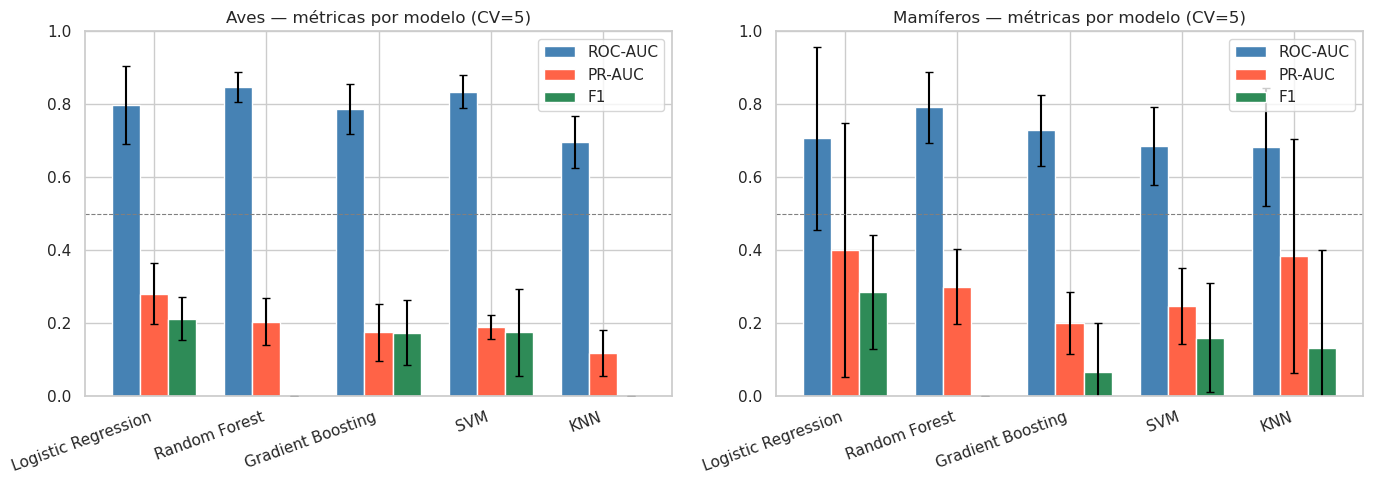

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, res_df) in zip(axes, [('Aves', res_aves), ('Mamíferos', res_mam)]):
    x = np.arange(len(res_df))
    w = 0.25
    ax.bar(x - w, res_df['ROC-AUC'], w, label='ROC-AUC', color='steelblue')
    ax.bar(x,     res_df['PR-AUC'],  w, label='PR-AUC',  color='tomato')
    ax.bar(x + w, res_df['F1'],      w, label='F1',       color='seagreen')
    ax.errorbar(x - w, res_df['ROC-AUC'], yerr=res_df['ROC-AUC±'], fmt='none', color='black', capsize=3)
    ax.errorbar(x,     res_df['PR-AUC'],  yerr=res_df['PR-AUC±'],  fmt='none', color='black', capsize=3)
    ax.errorbar(x + w, res_df['F1'],      yerr=res_df['F1±'],      fmt='none', color='black', capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(res_df.index, rotation=20, ha='right')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{nombre} — métricas por modelo (CV=5)', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_modelos_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Selección y refit del mejor modelo

In [18]:
mejor_aves = res_aves['ROC-AUC'].idxmax()
mejor_mam  = res_mam['ROC-AUC'].idxmax()

print(f'Mejor AVES:      {mejor_aves}  — ROC-AUC={res_aves.loc[mejor_aves, "ROC-AUC"]:.3f}')
print(f'Mejor MAMÍFEROS: {mejor_mam}   — ROC-AUC={res_mam.loc[mejor_mam, "ROC-AUC"]:.3f}')

# get_models() se llama dos veces → instancias completamente independientes
modelo_aves = get_models()[mejor_aves]
modelo_mam  = get_models()[mejor_mam]

modelo_aves.fit(X_aves, y_aves)
modelo_mam.fit(X_mam,  y_mam)

print(f'\nmodelo_aves.n_features_in_: {modelo_aves.n_features_in_}')
print(f'modelo_mam.n_features_in_:  {modelo_mam.n_features_in_}')

Mejor AVES:      Random Forest  — ROC-AUC=0.848
Mejor MAMÍFEROS: Random Forest   — ROC-AUC=0.792

modelo_aves.n_features_in_: 64
modelo_mam.n_features_in_:  29


In [19]:
# Loggear mejores modelos como artefactos MLflow
for clase, modelo, res_df, nombre in [
    ('Aves',      modelo_aves, res_aves, mejor_aves),
    ('Mamiferos', modelo_mam,  res_mam,  mejor_mam),
]:
    with mlflow.start_run(run_name=f"best_{clase}"):
        mlflow.log_param("clase",   clase)
        mlflow.log_param("modelo",  nombre)
        mlflow.log_metric("roc_auc", res_df.loc[nombre, 'ROC-AUC'])
        mlflow.log_metric("pr_auc",  res_df.loc[nombre, 'PR-AUC'])
        mlflow.log_metric("f1",      res_df.loc[nombre, 'F1'])
        mlflow.sklearn.log_model(modelo, artifact_path=f"modelo_{clase.lower()}")
        print(f"Loggeado: {clase} — {nombre}")

2026/04/01 23:19:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 23:19:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Loggeado: Aves — Random Forest
🏃 View run best_Aves at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/a8d0595e01974a79823d59fe654e80d5
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0


2026/04/01 23:19:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 23:19:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Loggeado: Mamiferos — Random Forest
🏃 View run best_Mamiferos at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0/runs/a0ea15d68bf9484ebb2fcf71179c7b47
🧪 View experiment at: https://dagshub.com/krilinxito/bioAlerta.mlflow/#/experiments/0


## 6. Feature Importance

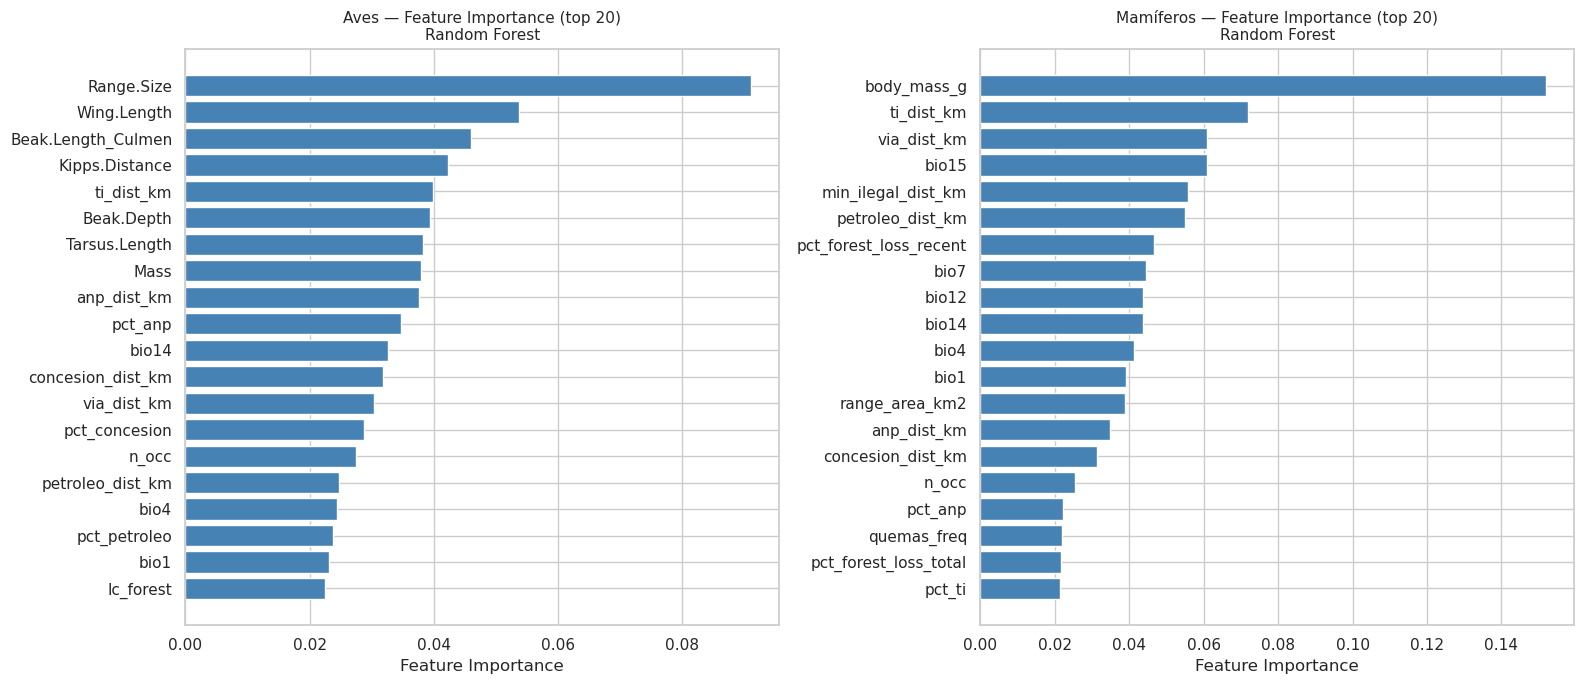

In [20]:
def get_feature_importance(modelo, top_n=20):
    """Extrae importancia usando feature_names_in_ del modelo ajustado."""
    clf = modelo.named_steps['clf'] if hasattr(modelo, 'named_steps') else modelo

    if hasattr(modelo, 'feature_names_in_'):
        feature_names = modelo.feature_names_in_
    elif hasattr(clf, 'feature_names_in_'):
        feature_names = clf.feature_names_in_
    else:
        feature_names = [f'f{i}' for i in range(clf.n_features_in_)]

    if hasattr(clf, 'feature_importances_'):
        imp = clf.feature_importances_
        tipo = 'Feature Importance'
    elif hasattr(clf, 'coef_'):
        imp = np.abs(clf.coef_[0])
        tipo = '|Coeficiente|'
    else:
        return None, None

    fi = pd.Series(imp, index=feature_names).sort_values(ascending=False)
    return fi.head(top_n), tipo


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (nombre, modelo, mn) in zip(axes, [
    ('Aves',      modelo_aves, mejor_aves),
    ('Mamíferos', modelo_mam,  mejor_mam),
]):
    fi, tipo = get_feature_importance(modelo, top_n=20)
    if fi is not None:
        ax.barh(fi.index[::-1], fi.values[::-1], color='steelblue')
        ax.set_title(f'{nombre} — {tipo} (top 20)\n{mn}', fontsize=11)
        ax.set_xlabel(tipo)
    else:
        ax.text(0.5, 0.5, 'Feature importance\nno disponible', ha='center', va='center')
        ax.set_title(f'{nombre} — {mn}')

plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_importancia_vars.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predicciones para especies sin IUCN

In [21]:
prob_aves = modelo_aves.predict_proba(X_aves_pred)[:, 1]
prob_mam  = modelo_mam.predict_proba(X_mam_pred)[:, 1]

# Umbral = prevalencia del train (correcto para desbalance severo)
umbral_aves = float(y_aves.mean())  # ~0.027
umbral_mam  = float(y_mam.mean())   # ~0.069

print(f'Umbral aves:      {umbral_aves:.4f}  ({umbral_aves*100:.1f}%)')
print(f'Umbral mamíferos: {umbral_mam:.4f}  ({umbral_mam*100:.1f}%)')

# Recuperar nombres de especies desde species_features (species es índice allí)
sf = pd.read_parquet(DATA / 'species_features.parquet')
nombres_aves = sf[(sf['class'] == 'Aves') & (sf['iucn_categoria'].isna())].index.to_numpy()
nombres_mam  = sf[(sf['class'] == 'Mammalia') & (sf['iucn_categoria'].isna())].index.to_numpy()

pred_aves = pd.DataFrame({
    'species':         nombres_aves,
    'class':           'Aves',
    'prob_threatened': prob_aves,
    'pred_threatened': (prob_aves >= umbral_aves).astype(int),
})

pred_mam = pd.DataFrame({
    'species':         nombres_mam,
    'class':           'Mammalia',
    'prob_threatened': prob_mam,
    'pred_threatened': (prob_mam >= umbral_mam).astype(int),
})

predicciones = pd.concat([pred_aves, pred_mam], ignore_index=True)
predicciones = predicciones.sort_values('prob_threatened', ascending=False).reset_index(drop=True)

print(f'\nTotal predichas: {len(predicciones)}')
print(f'  Aves:      {len(pred_aves)}  — amenazadas predichas: {pred_aves["pred_threatened"].sum()}')
print(f'  Mamíferos: {len(pred_mam)}  — amenazadas predichas: {pred_mam["pred_threatened"].sum()}')
print()
print('=== Top 20 con mayor riesgo predicho ===')
print(predicciones.head(20).to_string(index=False))

Umbral aves:      0.0274  (2.7%)
Umbral mamíferos: 0.0688  (6.9%)

Total predichas: 202
  Aves:      165  — amenazadas predichas: 31
  Mamíferos: 37  — amenazadas predichas: 18

=== Top 20 con mayor riesgo predicho ===
                species    class  prob_threatened  pred_threatened
             Ovis aries Mammalia         0.386667                1
         Dasypterus ega Mammalia         0.283333                1
         Equus caballus Mammalia         0.266667                1
 Pteronura brasiliensis Mammalia         0.266667                1
         Crax globulosa     Aves         0.236667                1
             Bos taurus Mammalia         0.236667                1
     Cinclodes aricomae     Aves         0.230000                1
    Charadrius alticola     Aves         0.226667                1
          Ateles chamek Mammalia         0.220000                1
       Inia geoffrensis Mammalia         0.186667                1
        Pauxi unicornis     Aves         0.1

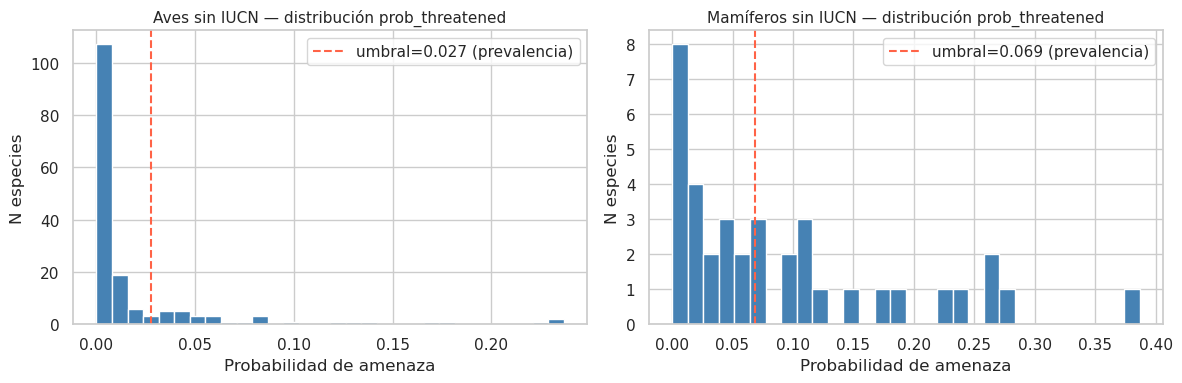

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nombre, df, umbral) in zip(axes, [
    ('Aves',      pred_aves, umbral_aves),
    ('Mamíferos', pred_mam,  umbral_mam),
]):
    ax.hist(df['prob_threatened'], bins=30, color='steelblue', edgecolor='white')
    ax.axvline(umbral, color='tomato', linestyle='--',
               label=f'umbral={umbral:.3f} (prevalencia)')
    ax.set_title(f'{nombre} sin IUCN — distribución prob_threatened', fontsize=11)
    ax.set_xlabel('Probabilidad de amenaza')
    ax.set_ylabel('N especies')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_pred_proba.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resumen y guardado

In [23]:
print('=== RESUMEN FINAL ===')
print()
print('AVES (1313 spp — 36 amenazadas, 1:35)')
print(res_aves[['ROC-AUC', 'PR-AUC', 'F1']].round(3).to_string())
print(f'  → Mejor: {mejor_aves}')
print()
print('MAMÍFEROS (189 spp — 13 amenazadas, 1:14)')
print(res_mam[['ROC-AUC', 'PR-AUC', 'F1']].round(3).to_string())
print(f'  → Mejor: {mejor_mam}')

=== RESUMEN FINAL ===

AVES (1313 spp — 36 amenazadas, 1:35)
                     ROC-AUC  PR-AUC     F1
modelo                                     
Logistic Regression    0.797   0.281  0.213
Random Forest          0.848   0.204  0.000
Gradient Boosting      0.786   0.175  0.174
SVM                    0.834   0.190  0.176
KNN                    0.696   0.118  0.000
  → Mejor: Random Forest

MAMÍFEROS (189 spp — 13 amenazadas, 1:14)
                     ROC-AUC  PR-AUC     F1
modelo                                     
Logistic Regression    0.707   0.401  0.286
Random Forest          0.792   0.300  0.000
Gradient Boosting      0.728   0.201  0.067
SVM                    0.686   0.248  0.161
KNN                    0.683   0.384  0.133
  → Mejor: Random Forest


In [24]:
import pyarrow as pa
import pyarrow.parquet as pq

# Reconstruir con dtypes numpy estándar (pandas 3.0 usa Arrow strings por default)
predicciones_out = pd.DataFrame({
    'species':         predicciones['species'].to_numpy(dtype=str),
    'class':           predicciones['class'].to_numpy(dtype=str),
    'prob_threatened': predicciones['prob_threatened'].to_numpy(dtype=float),
    'pred_threatened': predicciones['pred_threatened'].to_numpy(dtype=int),
})

pq.write_table(pa.Table.from_pandas(predicciones_out, preserve_index=False),
               DATA / 'predicciones.parquet')
print(f'Guardado: predicciones.parquet  ({len(predicciones_out)} especies)')

Guardado: predicciones.parquet  (202 especies)
